In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
df = pd.read_csv('df.csv',index_col=0).query('Q_threshold == 0.1')

df['F.F.-1 = D/N_emp'] = df['D'] / df['N_emp']
df['F.F.-1 = count2_sum/D - D/20**7 - 1'] = df['count2_sum']/df['D'] -  df['D'] /(20**7) - 1
df['D/N_emp'] = df['D'] / df['N_emp']
df

,filename,N_emp,D,count2_sum,unique_seqs,f1,f2,F_all,Q_threshold,label,F.F.-1 = D/N_emp,F.F.-1 = count2_sum/D - D/20**7 - 1,D/N_emp
0,TWIST_T0_cleaned.csv,1100000000,240537189,1006634905,98468089,42320482,23345912,2.997025,0.1,Original_TwistT0,0.218670,2.997025,0.218670
1,TWIST_T0_100.counts,11000000000,270877,287559,262765,254878,7666,0.061374,0.1,Pre-seq,0.000025,0.061374,0.000025
2,TWIST_T0_10.counts,1100000000,139501,147413,135674,131973,3578,0.056607,0.1,Pre-seq,0.000127,0.056607,0.000127
3,TWIST_T0_1.counts,110000000,131784,141390,127154,122690,4305,0.072789,0.1,Pre-seq,0.001198,0.072789,0.001198
4,TWIST_T0_01.counts,11000000,90990,113468,80864,71734,8232,0.246967,0.1,Pre-seq,0.008272,0.246967,0.008272
5,IAKOV_83_S7_R1_001.counts,11000000000,3087107,3214887,3025212,2964926,58793,0.038980,0.1,Forward-seq (FS),0.000281,0.038980,0.000281
6,IAKOV_83_S7_R2_001.counts,11000000000,5329095,5695323,5155047,4988273,160051,0.064559,0.1,Reverse-seq,0.000484,0.064559,0.000484
7,IAKOV_84_S8_R1_001.counts,1100000000,1042054,1079956,1023704,1005785,17552,0.035558,0.1,Forward-seq (FS),0.000947,0.035558,0.000947
8,IAKOV_84_S8_R2_001.counts,1100000000,1757721,1860845,1708776,1661484,45852,0.057296,0.1,Reverse-seq,0.001598,0.057296,0.001598
9,IAKOV_85_S9_R1_001.counts,110000000,1225262,1491882,1104308,994182,100312,0.216645,0.1,Forward-seq (FS),0.011139,0.216645,0.011139


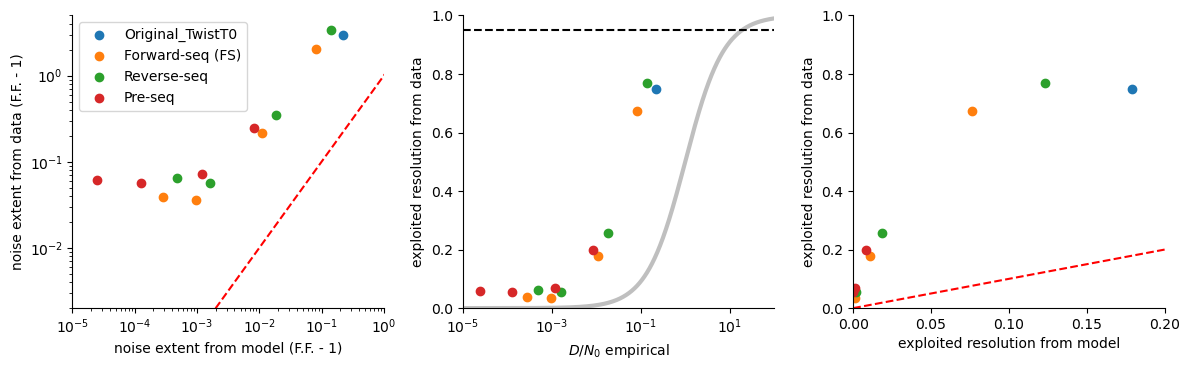

In [65]:
plt.figure(figsize=(12,3.8), facecolor='white')

types = ['Original_TwistT0','Forward-seq (FS)','Reverse-seq','Pre-seq']#,'FS Q_thresh = 0.05','FS Q_thresh = 0.005']
colors = ['C0','C1','C2','C3']#,'C1','C1']
markers = ['o','o','o','o']#,'x','*']

ax = plt.subplot(1,3,1)
i = 0
for type_ in types:
    df_sel = df[df['label'] == type_]
    plt.scatter(df_sel['F.F.-1 = D/N_emp'],df_sel['F.F.-1 = count2_sum/D - D/20**7 - 1'], label=type_, color=colors[i], marker=markers[i])
    i += 1
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-5,1)
plt.ylim(2e-3,5)
plt.xlabel('noise extent from model (F.F. - 1)')
plt.ylabel('noise extent from data (F.F. - 1)')
plt.plot([1e-5,10],[1e-5,10], linestyle='--', color='red')
ax.spines[['right', 'top']].set_visible(False)
plt.legend()

ax = plt.subplot(1,3,2)
i = 0
for type_ in types:
    df_sel = df[df['label'] == type_]
    y = df_sel['F.F.-1 = count2_sum/D - D/20**7 - 1']
    plt.scatter(df_sel['D/N_emp'], y/(1+y), label=type_, color=colors[i], marker=markers[i])
    
    i += 1

x = np.logspace(-5,2,1000)
plt.plot(x, x/(1+x), color='grey', linewidth = 3, alpha=0.5)
plt.hlines(0.95,1e-5,100,linestyle='--',color='black')
plt.xlim(1e-5,100)
plt.xscale('log')
plt.ylim(0,1)
ax.spines[['right', 'top']].set_visible(False)
plt.xlabel(r'$D/N_0$ empirical')
plt.ylabel('exploited resolution from data')

ax = plt.subplot(1,3,3)
i=0
for type_ in types:
    df_sel = df[df['label'] == type_]
    x = df_sel['D/N_emp']
    y = df_sel['F.F.-1 = count2_sum/D - D/20**7 - 1']
    plt.scatter(x/(1+x), y/(1+y), label=type_, color=colors[i], marker=markers[i])
    i += 1

plt.plot([0,0.3],[0,0.3],color='red',linestyle='--')
plt.ylim(0,1)
plt.xlim(0,0.2)
ax.spines[['right', 'top']].set_visible(False)
plt.xlabel('exploited resolution from model')
plt.ylabel('exploited resolution from data')

plt.tight_layout()
plt.savefig('figure4_002.png')

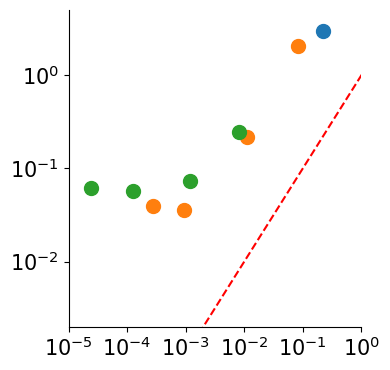

In [86]:
plt.figure(figsize=(4,3.8), facecolor='white')

#types = ['Original_TwistT0','Forward-seq (FS)','Reverse-seq','Pre-seq']
types = ['Original_TwistT0','Forward-seq (FS)','Pre-seq']

ax = plt.subplot(111)
for type_ in types:
    df_sel = df[df['label'] == type_]
    plt.scatter(df_sel['F.F.-1 = D/N_emp'],df_sel['F.F.-1 = count2_sum/D - D/20**7 - 1'], s=100)


plt.xscale('log')
plt.yscale('log')
plt.minorticks_off()
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(1e-5,1)
plt.ylim(2e-3,5)
#plt.xlabel('noise extent from model (F.F. - 1)')
#plt.ylabel('noise extent from data (F.F. - 1)')
plt.plot([1e-5,10],[1e-5,10], linestyle='--', color='red')
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('FF_emp_vs_FF_pred.png', dpi=1200)

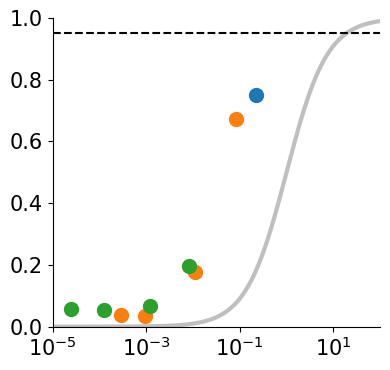

In [88]:
plt.figure(figsize=(4,3.8), facecolor='white')
ax = plt.subplot(111)

#types = ['Original_TwistT0','Forward-seq (FS)','Reverse-seq','Pre-seq']
types = ['Original_TwistT0','Forward-seq (FS)','Pre-seq']

i = 0
for type_ in types:
    df_sel = df[df['label'] == type_]
    y = df_sel['F.F.-1 = count2_sum/D - D/20**7 - 1']
    plt.scatter(df_sel['D/N_emp'], y/(1+y), s = 100)
    
    i += 1

x = np.logspace(-5,2,1000)
plt.plot(x, x/(1+x), color='grey', linewidth = 3, alpha=0.5)
plt.hlines(0.95,1e-5,100,linestyle='--',color='black')
plt.xlim(1e-5,100)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xscale('log')
plt.minorticks_off()
plt.ylim(0,1)
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.savefig('expl_res_emp_vs_D_N.png', dpi=1200)